In [20]:
!python.exe -m pip install pandas numpy lightgbm scikit-learn matplotlib seaborn scipy joblib



[notice] A new release of pip is available: 24.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, r2_score,
    classification_report, confusion_matrix, accuracy_score
)
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
import lightgbm as lgb

# Plot style
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['font.size'] = 12

print('All libraries loaded successfully')

All libraries loaded successfully


In [22]:
df = pd.read_csv('C:\\Users\\sanar\\OneDrive\\Desktop\\autoinsightcs70-main\\autoinsightcs70\\model_training\\dataset_with_model_first_name.csv')

print(f'Dataset shape: {df.shape}')
print(f'\nColumns: {df.columns.tolist()}')
df.head()

Dataset shape: (23430, 11)

Columns: ['Unnamed: 0', 'Vehicle Type', 'Make', 'Model', 'Year', 'Price', 'Milleage', 'District', 'published date', 'Vehicle URL', 'Condition']


,Unnamed: 0,Vehicle Type,Make,Model,Year,Price,Milleage,District,published date,Vehicle URL,Condition
0,0,Car,Toyota,AXIO,2008.0,7150000.0,178000.0,Colombo,2/1/2026,https://riyasewana.com/buy/toyota-axio-sale-co...,Used
1,1,Car,Suzuki,WAGON R,2016.0,5690000.0,79000.0,Ragama,2/7/2026,https://riyasewana.com/buy/suzuki-wagon-r-sale...,Used
2,3,Car,Suzuki,ALTO,2023.0,6590000.0,9900.0,Kiribathgoda,2/7/2026,https://riyasewana.com/buy/suzuki-alto-japan-s...,Recondition
3,5,Car,Suzuki,ALTO,2011.0,3245000.0,156100.0,Veyangoda,2/7/2026,https://riyasewana.com/buy/suzuki-alto-k10-sal...,Used
4,6,Car,Mazda,6,2013.0,12200000.0,76000.0,Colombo,2/7/2026,https://riyasewana.com/buy/mazda-6-sale-colomb...,Used


In [23]:
df = df[df['Price'] < 30_000_000].copy()
df = df[df['Milleage'] < 1_000_000].copy()

df = df.dropna(subset=['Price', 'Milleage', 'Year'])

for col in ['Make', 'Model', 'District', 'Condition']:
    df[col] = df[col].fillna('Unknown')

print(f'Rows after cleaning: {df.shape[0]}')
print(f'\nNull values remaining:')
print(df[['Year', 'Price', 'Milleage', 'Make', 'Model', 'District', 'Condition']].isnull().sum())

Rows after cleaning: 23407

Null values remaining:
Year         0
Price        0
Milleage     0
Make         0
Model        0
District     0
Condition    0
dtype: int64


In [24]:
FEATURES = ['Year', 'Milleage', 'Make', 'Model', 'District', 'Condition']
TARGET   = 'Price'

df_ml = df[FEATURES + [TARGET]].copy()

label_encoders = {}
for col in ['Make', 'Model', 'District', 'Condition']:
    le = LabelEncoder()
    df_ml[col] = le.fit_transform(df_ml[col].astype(str))
    label_encoders[col] = le

X = df_ml[FEATURES]
y = df_ml[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f'Training samples : {len(X_train)}')
print(f'Testing  samples : {len(X_test)}')
print(f'Features used    : {FEATURES}')

Training samples : 18725
Testing  samples : 4682
Features used    : ['Year', 'Milleage', 'Make', 'Model', 'District', 'Condition']


In [25]:
models = {
    'Linear Regression' : LinearRegression(),
    'Decision Tree'     : DecisionTreeRegressor(random_state=42, max_depth=10),
    'Random Forest'     : RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1),
    'LightGBM'          : lgb.LGBMRegressor(
                              n_estimators=500,
                              learning_rate=0.05,
                              num_leaves=63,
                              random_state=42,
                              verbose=-1
                          ),
}

results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred_train = model.predict(X_train)
    y_pred_test  = model.predict(X_test)

    results[name] = {
        'model'        : model,
        'y_pred_train' : y_pred_train,
        'y_pred_test'  : y_pred_test,
        'train_mae'    : mean_absolute_error(y_train, y_pred_train),
        'train_mse'    : mean_squared_error(y_train, y_pred_train),
        'train_rmse'   : np.sqrt(mean_squared_error(y_train, y_pred_train)),
        'train_r2'     : r2_score(y_train, y_pred_train),
        'test_mae'     : mean_absolute_error(y_test, y_pred_test),
        'test_mse'     : mean_squared_error(y_test, y_pred_test),
        'test_rmse'    : np.sqrt(mean_squared_error(y_test, y_pred_test)),
        'test_r2'      : r2_score(y_test, y_pred_test),
        'residuals'    : y_test.values - y_pred_test,
    }
    print(f' {name} trained')

print('\n All models trained!')

 Linear Regression trained
 Decision Tree trained
 Random Forest trained
 LightGBM trained

 All models trained!


In [26]:
rows = []
for name, r in results.items():
    rows.append({
        'Model'      : name,
        'MAE (LKR)'  : f"{r['test_mae']:,.0f}",
        'MSE'        : f"{r['test_mse']:.2e}",
        'RMSE (LKR)' : f"{r['test_rmse']:,.0f}",
        'R² Score'   : f"{r['test_r2']:.4f}",
    })

metrics_df = pd.DataFrame(rows).set_index('Model')
print('=== TEST SET ERROR METRICS ===')
metrics_df

=== TEST SET ERROR METRICS ===


,MAE (LKR),MSE,RMSE (LKR),R² Score
Model,,,,
Linear Regression,"3,017,171",1.86e+13,"4,312,526",0.2650
Decision Tree,"1,346,460",6.22e+12,"2,494,294",0.7541
Random Forest,"947,452",3.68e+12,"1,917,739",0.8546
LightGBM,"985,067",3.61e+12,"1,898,937",0.8575


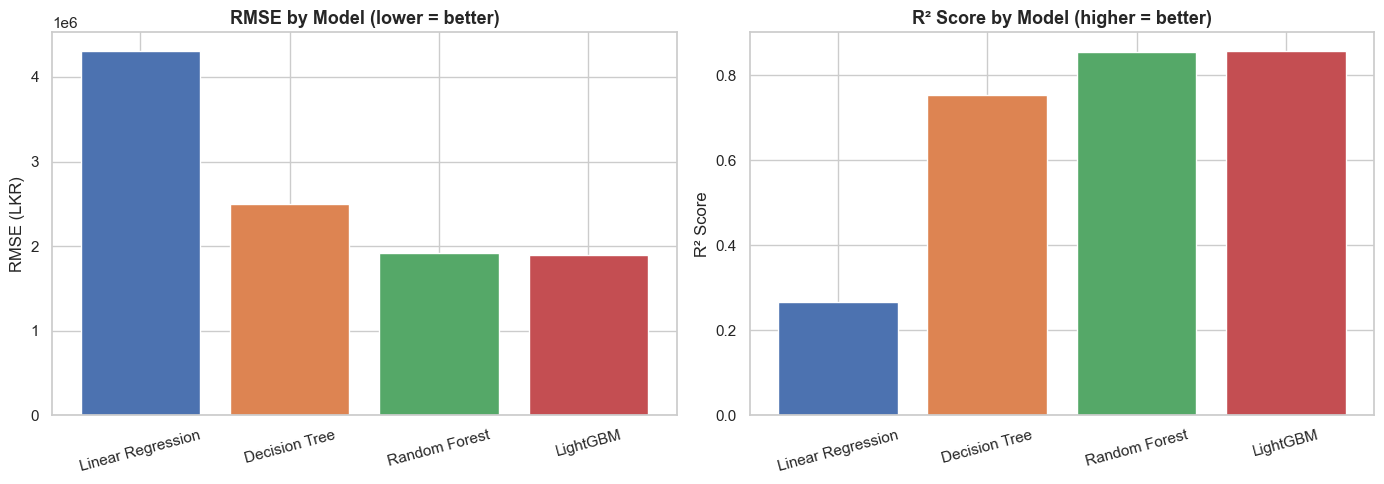

In [27]:
rmse_vals = {name: r['test_rmse'] for name, r in results.items()}
r2_vals   = {name: r['test_r2']   for name, r in results.items()}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].bar(rmse_vals.keys(), rmse_vals.values(), color=['#4C72B0','#DD8452','#55A868','#C44E52'])
axes[0].set_title('RMSE by Model (lower = better)', fontsize=13, fontweight='bold')
axes[0].set_ylabel('RMSE (LKR)')
axes[0].tick_params(axis='x', rotation=15)

axes[1].bar(r2_vals.keys(), r2_vals.values(), color=['#4C72B0','#DD8452','#55A868','#C44E52'])
axes[1].set_title('R² Score by Model (higher = better)', fontsize=13, fontweight='bold')
axes[1].set_ylabel('R² Score')
axes[1].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.savefig('error_metrics_comparison.png', bbox_inches='tight', dpi=150)
plt.show()

In [28]:
print('=== TRAIN vs TEST R² SCORES ===')
print(f'{"Model":<22} {"Train R²":>10} {"Test R²":>10} {"Gap":>10} {"Diagnosis":>15}')
print('-' * 70)

for name, r in results.items():
    gap = r['train_r2'] - r['test_r2']
    if gap > 0.15:
        diagnosis = '  Overfitting'
    elif r['test_r2'] < 0.5:
        diagnosis = '  Underfitting'
    else:
        diagnosis = ' Good fit'
    print(f"{name:<22} {r['train_r2']:>10.4f} {r['test_r2']:>10.4f} {gap:>10.4f} {diagnosis:>15}")

=== TRAIN vs TEST R² SCORES ===
Model                    Train R²    Test R²        Gap       Diagnosis
----------------------------------------------------------------------
Linear Regression          0.2683     0.2650     0.0033    Underfitting
Decision Tree              0.8096     0.7541     0.0555        Good fit
Random Forest              0.9767     0.8546     0.1221        Good fit
LightGBM                   0.9197     0.8575     0.0622        Good fit


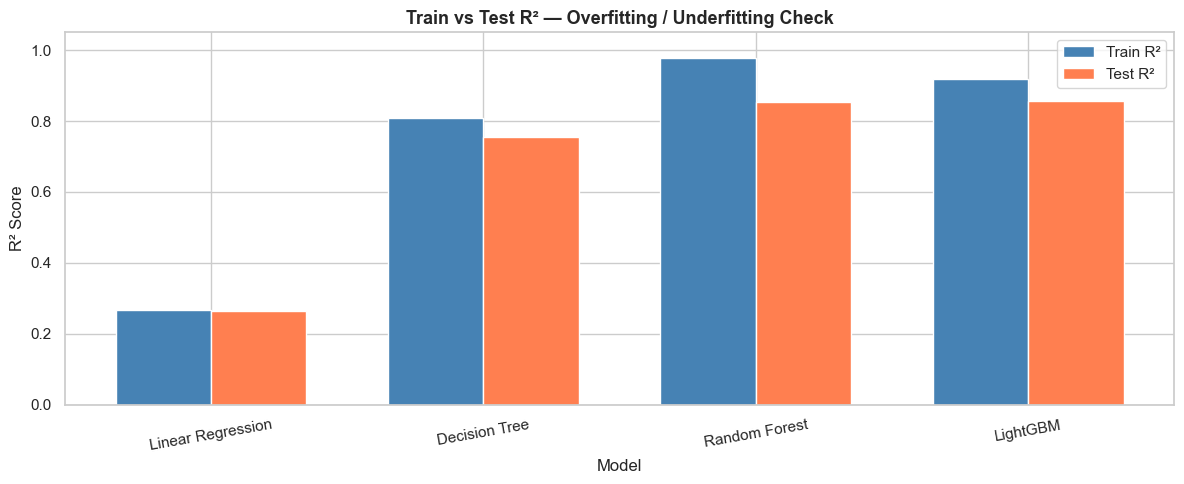

In [29]:
model_names = list(results.keys())
train_r2s   = [results[n]['train_r2'] for n in model_names]
test_r2s    = [results[n]['test_r2']  for n in model_names]

x     = np.arange(len(model_names))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(x - width/2, train_r2s, width, label='Train R²', color='steelblue')
ax.bar(x + width/2, test_r2s,  width, label='Test R²',  color='coral')
ax.set_xlabel('Model')
ax.set_ylabel('R² Score')
ax.set_title('Train vs Test R² — Overfitting / Underfitting Check', fontsize=13, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(model_names, rotation=10)
ax.legend()
ax.set_ylim(0, 1.05)
plt.tight_layout()
plt.savefig('train_vs_test_r2.png', bbox_inches='tight', dpi=150)
plt.show()

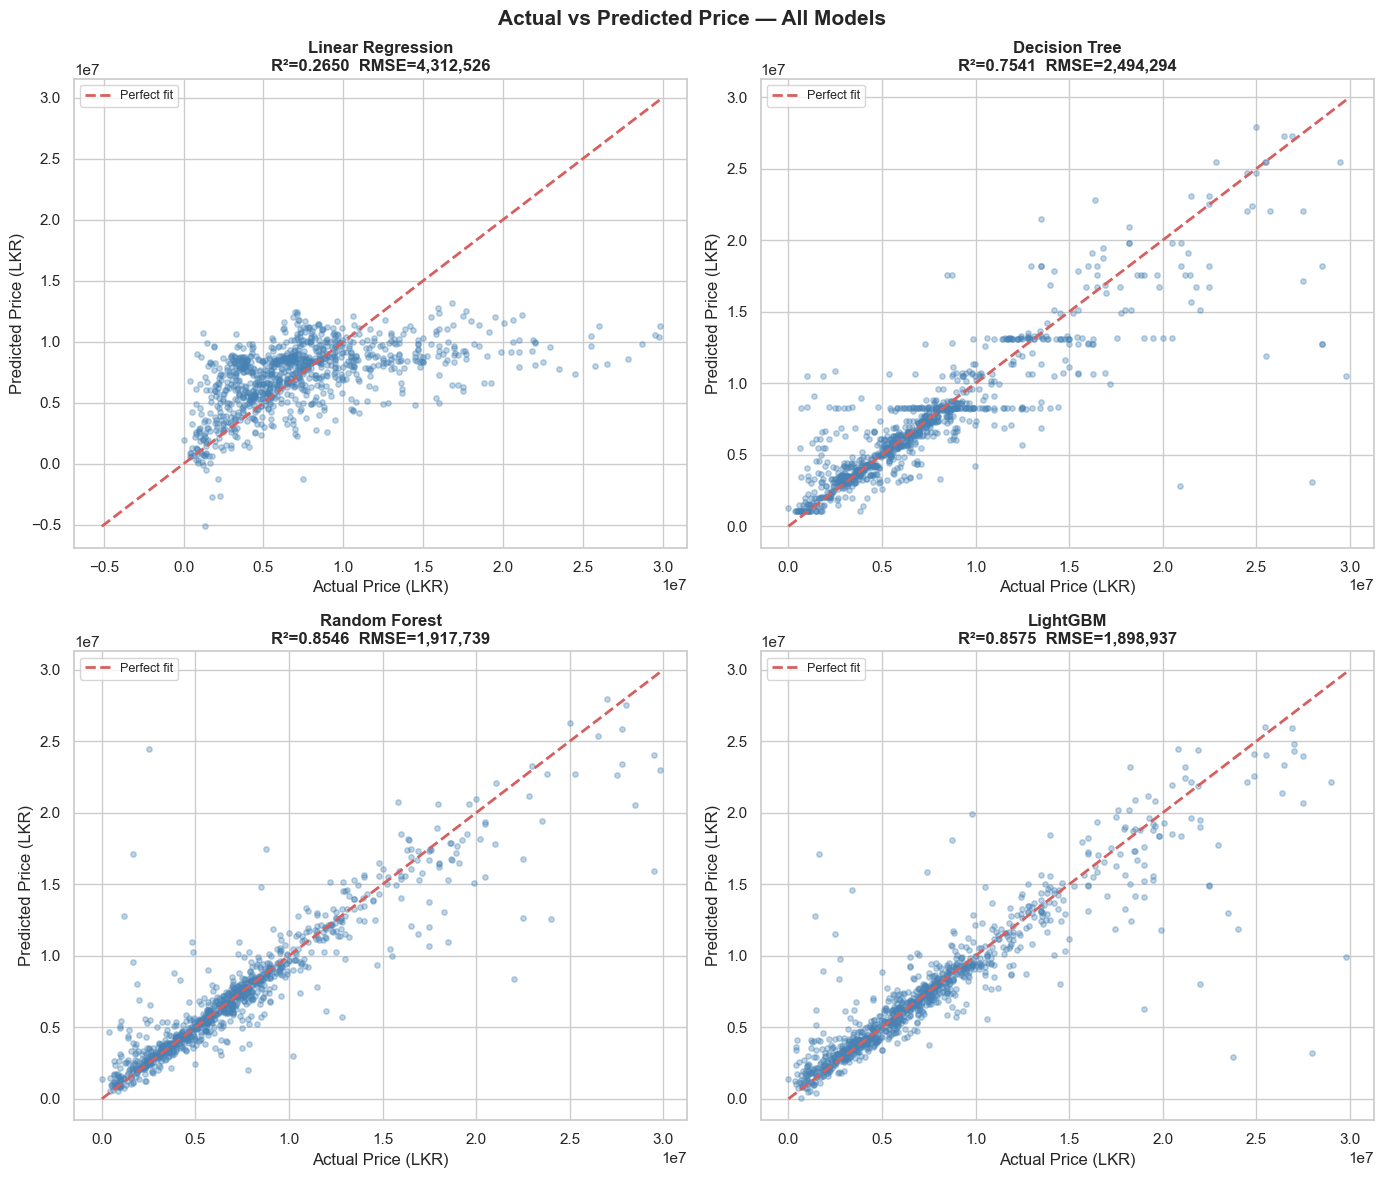

In [30]:
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
axes = axes.flatten()

for i, (name, r) in enumerate(results.items()):
    ax  = axes[i]
    idx = np.random.choice(len(y_test), size=min(1000, len(y_test)), replace=False)
    actual    = y_test.values[idx]
    predicted = r['y_pred_test'][idx]

    ax.scatter(actual, predicted, alpha=0.35, s=15, color='steelblue')
    min_val = min(actual.min(), predicted.min())
    max_val = max(actual.max(), predicted.max())
    ax.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='Perfect fit')
    ax.set_xlabel('Actual Price (LKR)')
    ax.set_ylabel('Predicted Price (LKR)')
    ax.set_title(f'{name}\nR²={r["test_r2"]:.4f}  RMSE={r["test_rmse"]:,.0f}', fontweight='bold')
    ax.legend(fontsize=9)

plt.suptitle('Actual vs Predicted Price — All Models', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('actual_vs_predicted.png', bbox_inches='tight', dpi=150)
plt.show()

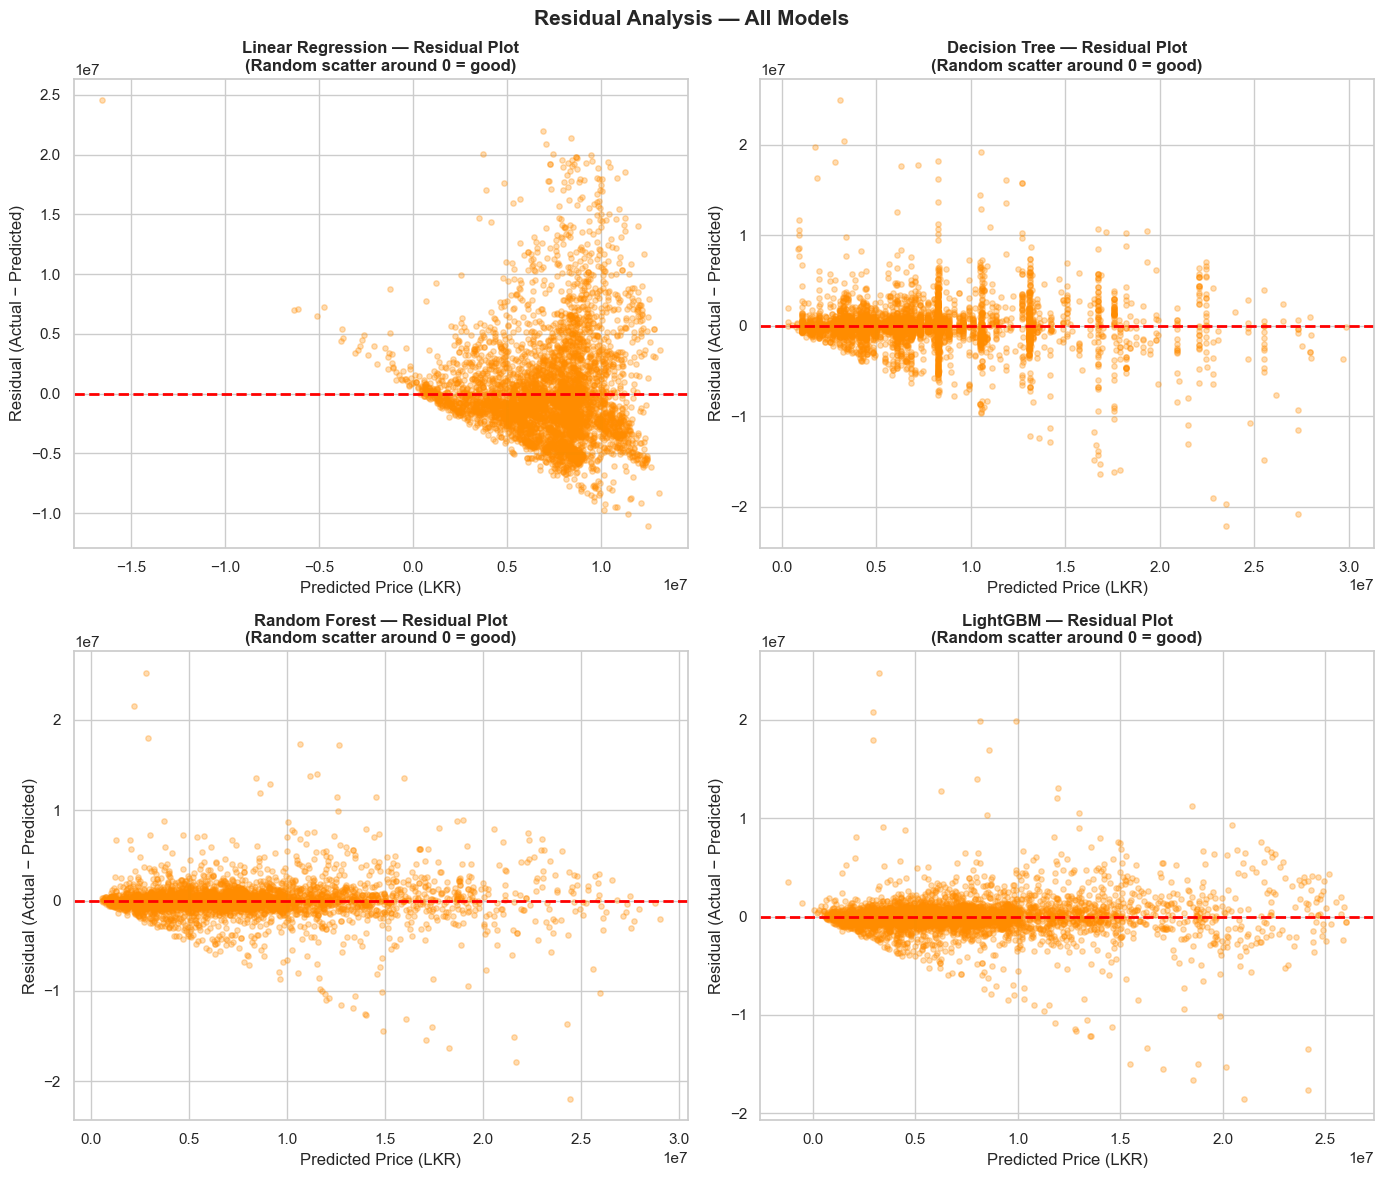

In [31]:
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
axes = axes.flatten()

for i, (name, r) in enumerate(results.items()):
    ax        = axes[i]
    residuals = r['residuals']
    ax.scatter(r['y_pred_test'], residuals, alpha=0.3, s=15, color='darkorange')
    ax.axhline(0, color='red', linestyle='--', lw=2)
    ax.set_xlabel('Predicted Price (LKR)')
    ax.set_ylabel('Residual (Actual − Predicted)')
    ax.set_title(f'{name} — Residual Plot\n(Random scatter around 0 = good)', fontweight='bold')

plt.suptitle('Residual Analysis — All Models', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('residual_analysis.png', bbox_inches='tight', dpi=150)
plt.show()

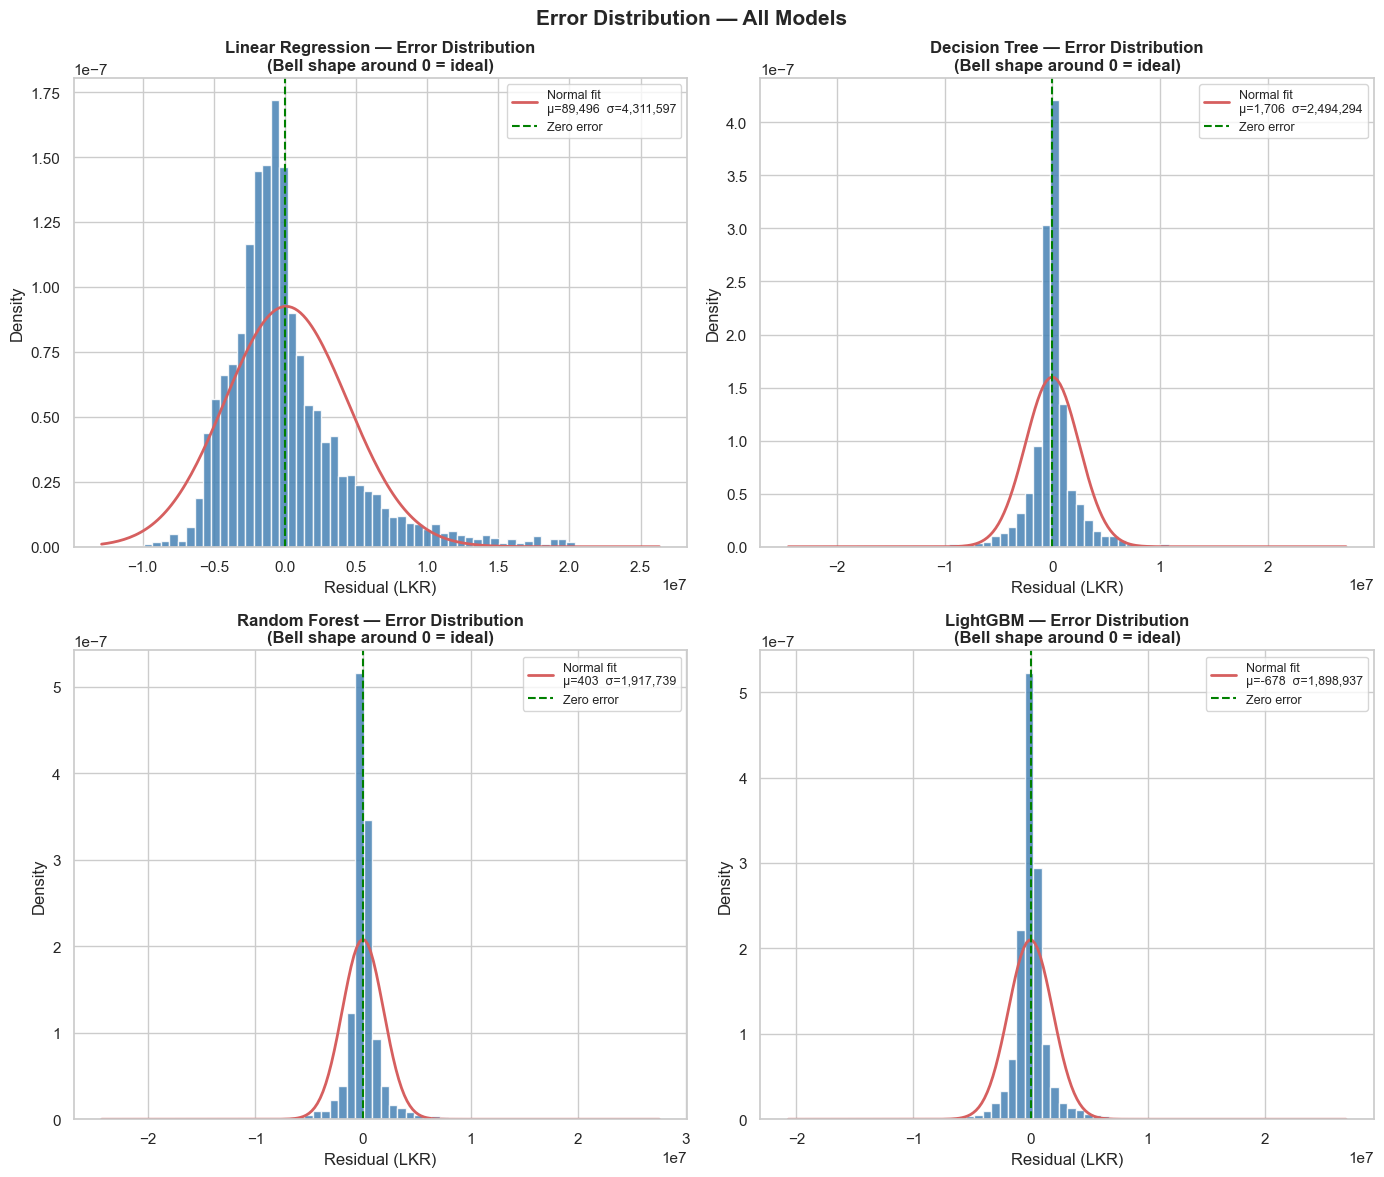

In [32]:
from scipy.stats import norm   # ← add this one line at the top

fig, axes = plt.subplots(2, 2, figsize=(14, 12))
axes = axes.flatten()

for i, (name, r) in enumerate(results.items()):
    ax        = axes[i]
    residuals = r['residuals']
    ax.hist(residuals, bins=60, color='steelblue', edgecolor='white', alpha=0.85, density=True)
    mu, std     = norm.fit(residuals)
    xmin, xmax  = ax.get_xlim()
    xs = np.linspace(xmin, xmax, 200)
    ax.plot(xs, norm.pdf(xs, mu, std), 'r-', lw=2, label=f'Normal fit\nμ={mu:,.0f}  σ={std:,.0f}')
    ax.axvline(0, color='green', linestyle='--', lw=1.5, label='Zero error')
    ax.set_xlabel('Residual (LKR)')
    ax.set_ylabel('Density')
    ax.set_title(f'{name} — Error Distribution\n(Bell shape around 0 = ideal)', fontweight='bold')
    ax.legend(fontsize=9)

plt.suptitle('Error Distribution — All Models', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('error_distribution.png', bbox_inches='tight', dpi=150)
plt.show()

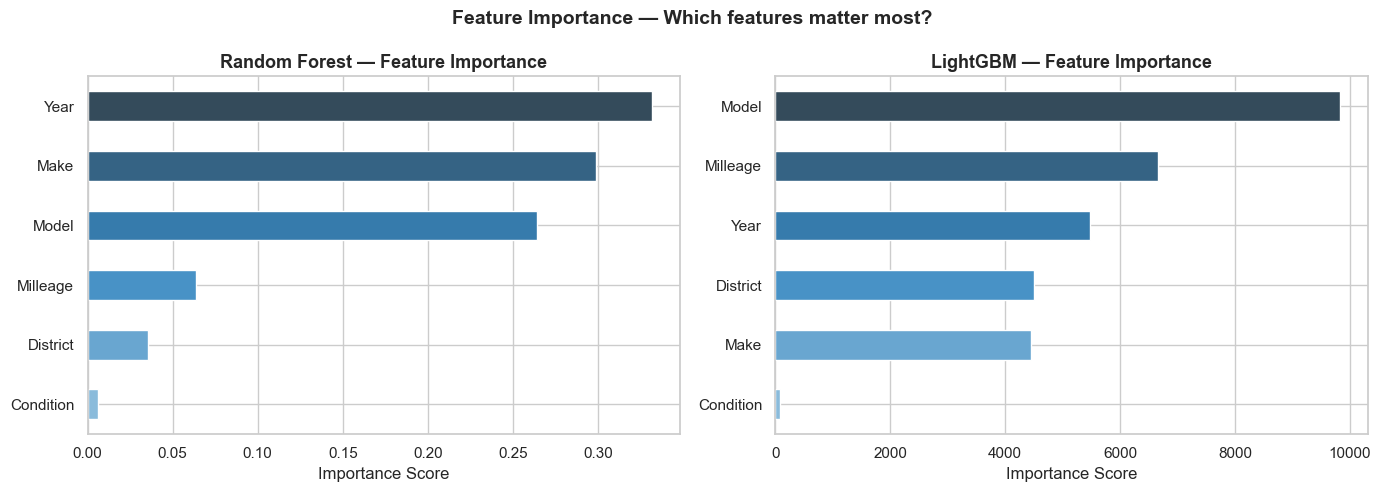

In [33]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, key in zip(axes, ['Random Forest', 'LightGBM']):
    model       = results[key]['model']
    importances = model.feature_importances_
    feat_imp    = pd.Series(importances, index=FEATURES).sort_values(ascending=True)
    colors      = sns.color_palette('Blues_d', len(feat_imp))
    feat_imp.plot(kind='barh', ax=ax, color=colors)
    ax.set_title(f'{key} — Feature Importance', fontsize=13, fontweight='bold')
    ax.set_xlabel('Importance Score')

plt.suptitle('Feature Importance — Which features matter most?', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('feature_importance.png', bbox_inches='tight', dpi=150)
plt.show()

In [41]:
kf         = KFold(n_splits=5, shuffle=True, random_state=42)
cv_results = {}

print('Running 5-Fold Cross Validation...\n')
print(f'{"Model":<22} {"CV R² Mean":>12} {"CV R² Std":>12} {"Stability":>12}')
print('-' * 62)

for name, r in results.items():
    cv_scores        = cross_val_score(r['model'], X, y, cv=kf, scoring='r2', n_jobs=-1)
    cv_results[name] = cv_scores
    stability        = ' Stable' if cv_scores.std() < 0.05 else '  Unstable'
    print(f"{name:<22} {cv_scores.mean():>12.4f} {cv_scores.std():>12.4f} {stability:>12}")

Running 5-Fold Cross Validation...

Model                    CV R² Mean    CV R² Std    Stability
--------------------------------------------------------------
Linear Regression            0.2672       0.0067       Stable
Decision Tree                0.7417       0.0126       Stable
Random Forest                0.8444       0.0066       Stable
LightGBM                     0.8472       0.0076       Stable


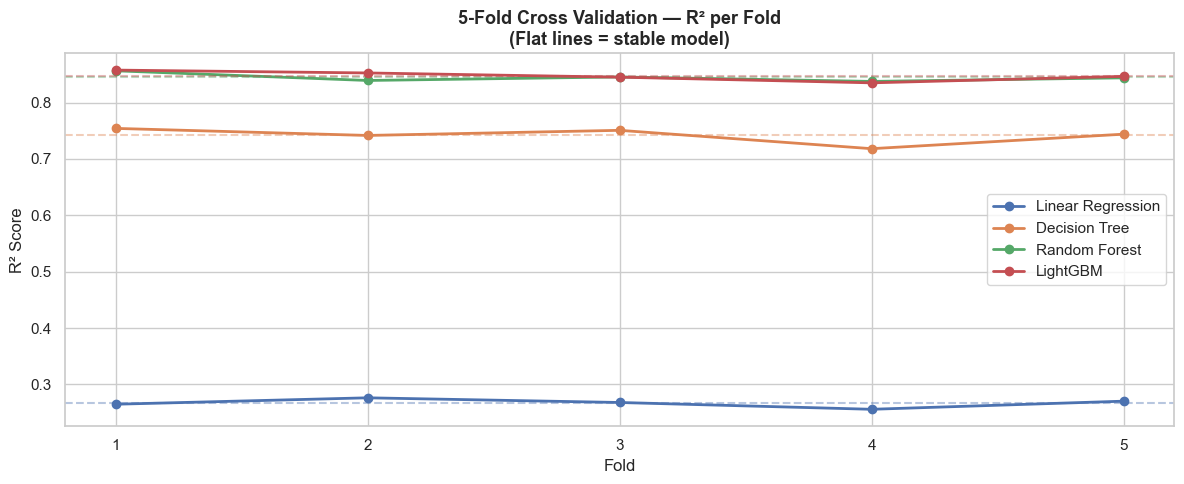

In [35]:
fig, ax = plt.subplots(figsize=(12, 5))
colors  = ['#4C72B0','#DD8452','#55A868','#C44E52']

for i, (name, scores) in enumerate(cv_results.items()):
    ax.plot(range(1, 6), scores, marker='o', label=name, color=colors[i], lw=2)
    ax.axhline(scores.mean(), color=colors[i], linestyle='--', alpha=0.4)

ax.set_xlabel('Fold')
ax.set_ylabel('R² Score')
ax.set_title('5-Fold Cross Validation — R² per Fold\n(Flat lines = stable model)', fontsize=13, fontweight='bold')
ax.legend()
ax.set_xticks(range(1, 6))
plt.tight_layout()
plt.savefig('cross_validation.png', bbox_inches='tight', dpi=150)
plt.show()

In [36]:
print('=== BIAS vs VARIANCE ANALYSIS ===')
print(f'{"Model":<22} {"Train R²":>10} {"Test R²":>10} {"CV Std":>10} {"Verdict":>22}')
print('-' * 80)

for name, r in results.items():
    train_r2 = r['train_r2']
    test_r2  = r['test_r2']
    cv_std   = cv_results[name].std()
    gap      = train_r2 - test_r2

    if test_r2 < 0.5 and train_r2 < 0.6:
        verdict = ' High Bias (Underfit)'
    elif gap > 0.15 or cv_std > 0.05:
        verdict = ' High Variance (Overfit)'
    else:
        verdict = ' Good Balance'

    print(f"{name:<22} {train_r2:>10.4f} {test_r2:>10.4f} {cv_std:>10.4f} {verdict:>22}")

=== BIAS vs VARIANCE ANALYSIS ===
Model                    Train R²    Test R²     CV Std                Verdict
--------------------------------------------------------------------------------
Linear Regression          0.2683     0.2650     0.0067   High Bias (Underfit)
Decision Tree              0.8096     0.7541     0.0126           Good Balance
Random Forest              0.9767     0.8546     0.0066           Good Balance
LightGBM                   0.9197     0.8575     0.0076           Good Balance


In [37]:
summary_rows = []
for name, r in results.items():
    summary_rows.append({
        'Model'       : name,
        'Test MAE'    : round(r['test_mae']),
        'Test RMSE'   : round(r['test_rmse']),
        'Test R²'     : round(r['test_r2'], 4),
        'CV R² Mean'  : round(cv_results[name].mean(), 4),
        'CV R² Std'   : round(cv_results[name].std(), 4),
        'Train R²'    : round(r['train_r2'], 4),
        'Overfit Gap' : round(r['train_r2'] - r['test_r2'], 4),
    })

summary_df = pd.DataFrame(summary_rows).set_index('Model')
summary_df = summary_df.sort_values('Test R²', ascending=False)
print('=== FINAL MODEL COMPARISON (sorted by Test R²) ===')
summary_df

=== FINAL MODEL COMPARISON (sorted by Test R²) ===


,Test MAE,Test RMSE,Test R²,CV R² Mean,CV R² Std,Train R²,Overfit Gap
Model,,,,,,,
LightGBM,985067,1898937,0.8575,0.8472,0.0076,0.9197,0.0622
Random Forest,947452,1917739,0.8546,0.8444,0.0066,0.9767,0.1221
Decision Tree,1346460,2494294,0.7541,0.7417,0.0126,0.8096,0.0555
Linear Regression,3017171,4312526,0.2650,0.2672,0.0067,0.2683,0.0033


In [39]:
best_model_name = summary_df.index[0]
best_r2         = summary_df.loc[best_model_name, 'Test R²']
best_rmse       = summary_df.loc[best_model_name, 'Test RMSE']
best_mae        = summary_df.loc[best_model_name, 'Test MAE']

print('=' * 55)
print(f'    BEST MODEL  →  {best_model_name}')
print('=' * 55)
print(f'  R² Score : {best_r2}')
print(f'  RMSE     : LKR {best_rmse:,}')
print(f'  MAE      : LKR {best_mae:,}')
print('=' * 55)

    BEST MODEL  →  LightGBM
  R² Score : 0.8575
  RMSE     : LKR 1,898,937
  MAE      : LKR 985,067


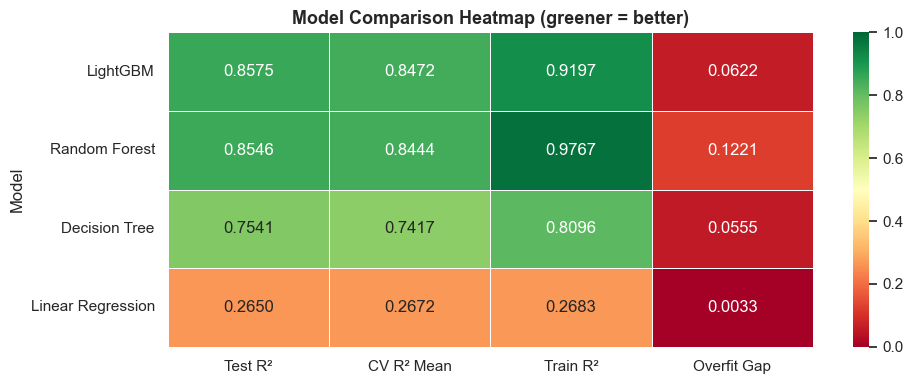

In [40]:
heat_data = summary_df[['Test R²','CV R² Mean','Train R²','Overfit Gap']].copy()

fig, ax = plt.subplots(figsize=(10, 4))
sns.heatmap(
    heat_data.astype(float),
    annot=True, fmt='.4f', cmap='RdYlGn',
    linewidths=0.5, ax=ax, vmin=0, vmax=1
)
ax.set_title('Model Comparison Heatmap (greener = better)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('model_comparison_heatmap.png', bbox_inches='tight', dpi=150)
plt.show()